In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np


In [2]:
class TanhNet(nn.Module):
    def __init__(self):
        super(TanhNet, self).__init__()

        # First fully connected layer
        self.fc1 = nn.Linear(2, 3)

        # Second fully connected layer
        self.fc2 = nn.Linear(3, 1)

    def forward(self, x):
        
        # Pass data through fc1
        x = self.fc1(x)

        # Use the tanh activation function over x
        x = F.tanh(x)

        # Pass data through 
        x = self.fc2(x)

        output = x
        return output

class ReluNet(nn.Module):
    def __init__(self):
        super(ReluNet, self).__init__()

        # First fully connected layer
        self.fc1 = nn.Linear(2, 3)

        # Second fully connected layer
        self.fc2 = nn.Linear(3, 1)

    def forward(self, x):
        
        # Pass data through fc1
        x = self.fc1(x)

        # Use the tanh activation function over x
        x = F.relu(x)

        # Pass data through 
        x = self.fc2(x)

        output = x
        return output


class SoftplusNet(nn.Module):
    def __init__(self):
        super(SoftplusNet, self).__init__()

        # First fully connected layer
        self.fc1 = nn.Linear(2, 3)

        # Second fully connected layer
        self.fc2 = nn.Linear(3, 1)

    def forward(self, x):
        
        # Pass data through fc1
        x = self.fc1(x)

        # Use the tanh activation function over x
        x = F.softplus(x)

        # Pass data through 
        x = self.fc2(x)

        output = x
        return output


## Create some interrogation signals

Here we create some interrogation signals to test the networks


Text(0.5, 1.0, 'Interrogation Signals')

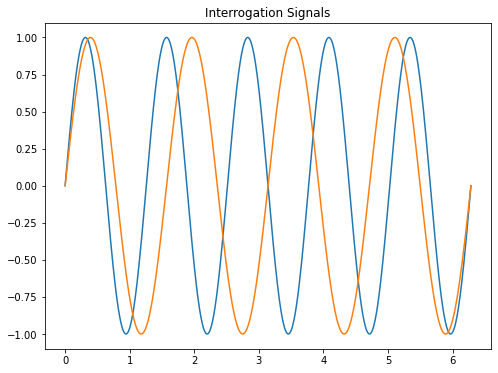

In [3]:
n_samples = 1000
t = np.linspace(0, 2*np.pi, n_samples)
w1 = 5
w2 = 4

x1 = np.sin(w1*t)
x2 = np.sin(w2*t)

x = np.hstack(
    (x1.reshape(-1, 1), x2.reshape(-1,1)))

fig, axs = plt.subplots(figsize=(8,6))
axs.plot(t, x)
axs.set_title('Interrogation Signals')

## Pass data through the network to test it

Here we pass some simple data through the network to plot its output.

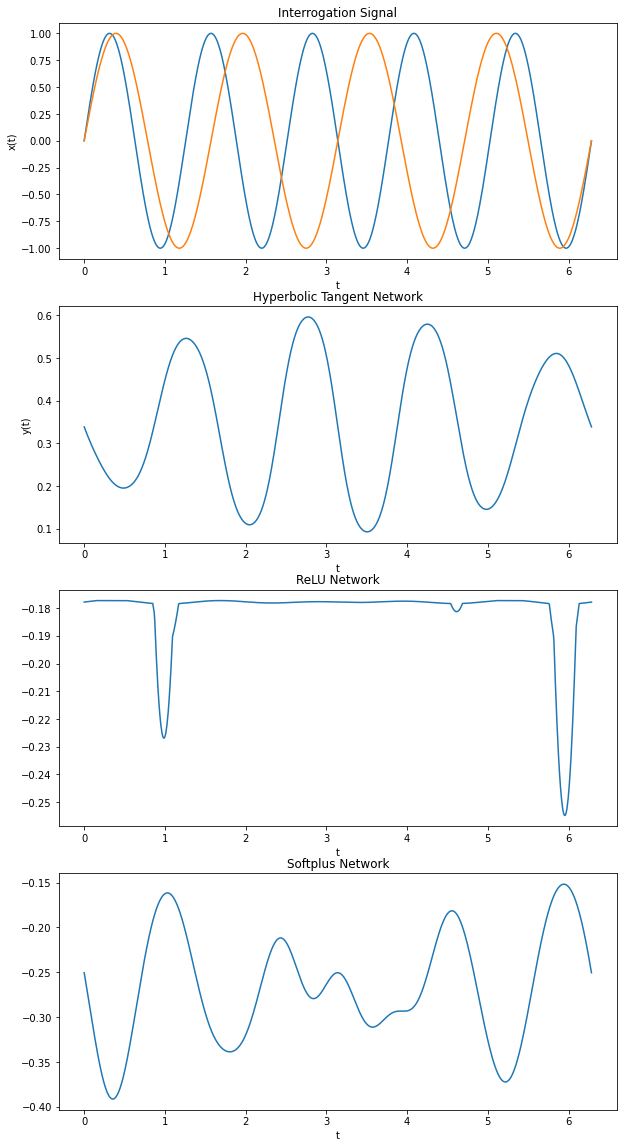

In [4]:
    
tanh_nn = TanhNet()
relu_nn = ReluNet()
softplus_nn = SoftplusNet()

x_torch = torch.from_numpy(x).float()

y_tanh_torch = tanh_nn(x_torch)
y_relu_torch = relu_nn(x_torch)
y_softplus_torch = softplus_nn(x_torch)

y_tanh = y_tanh_torch.detach().numpy()
y_relu = y_relu_torch.detach().numpy()
y_softplus = y_softplus_torch.detach().numpy()

fig, axs = plt.subplots(4,1, figsize=(10,20))

axs[0].set_title('Interrogation Signal')
axs[0].set_xlabel('t')
axs[0].set_ylabel('x(t)')
axs[0].plot(t, x)

axs[1].set_title('Hyperbolic Tangent Network')
axs[1].set_xlabel('t')
axs[1].set_ylabel('y(t)')
axs[1].plot(t, y_tanh)

axs[2].set_title('ReLU Network')
axs[2].set_xlabel('t')
axs[2].set_label('y(t)')
axs[2].plot(t, y_relu)

axs[3].set_title('Softplus Network')
axs[3].set_xlabel('t')
axs[3].set_label('y(t)')
axs[3].plot(t, y_softplus)


## Print the model parameters

Here we print the model parameters so we can verify that we can recode each from scrath.


In [5]:
print('\n\ntanh_nn parameters:\n')

for name, param in tanh_nn.named_parameters():
    print(name)
    print(param)

print('\n\nrelu_nn parameters:\n')

for name, param in relu_nn.named_parameters():
    print(name)
    print(param)

print('\n\nsoftplus_nn parameters:\n')

for name, param in softplus_nn.named_parameters():
    print(name)
    print(param)




tanh_nn parameters:

fc1.weight
Parameter containing:
tensor([[ 0.1308,  0.0086],
        [ 0.1928, -0.5408],
        [ 0.1704,  0.4667]], requires_grad=True)
fc1.bias
Parameter containing:
tensor([ 0.3142, -0.0012, -0.3002], requires_grad=True)
fc2.weight
Parameter containing:
tensor([[-0.4313,  0.5557,  0.1735]], requires_grad=True)
fc2.bias
Parameter containing:
tensor([0.5209], requires_grad=True)


relu_nn parameters:

fc1.weight
Parameter containing:
tensor([[-0.5109, -0.1764],
        [-0.3114, -0.2354],
        [-0.6097, -0.3927]], requires_grad=True)
fc1.bias
Parameter containing:
tensor([-0.5384,  0.3593, -0.6468], requires_grad=True)
fc2.weight
Parameter containing:
tensor([[-0.3675, -0.0015, -0.0704]], requires_grad=True)
fc2.bias
Parameter containing:
tensor([-0.1773], requires_grad=True)


softplus_nn parameters:

fc1.weight
Parameter containing:
tensor([[-0.0531,  0.6440],
        [ 0.5657, -0.2005],
        [ 0.0743, -0.4097]], requires_grad=True)
fc1.bias
Parameter c

## Extract specific parameters

Here we extract specific parameters so we can use them to reconstruct the networks.


In [6]:
class NetworkParams():

    def __init__(self, weight1, bias1, weight2, bias2):
        self.weight1 = weight1
        self.bias1 = bias1.reshape(-1,1)
        self.weight2 = weight2
        self.bias2 = bias2.reshape(-1,1)


tanh_params = NetworkParams(
    tanh_nn.fc1.weight.detach().numpy(),
    tanh_nn.fc1.bias.detach().numpy(),
    tanh_nn.fc2.weight.detach().numpy(),
    tanh_nn.fc2.bias.detach().numpy())

relu_params = NetworkParams(
    relu_nn.fc1.weight.detach().numpy(),
    relu_nn.fc1.bias.detach().numpy(),
    relu_nn.fc2.weight.detach().numpy(),
    relu_nn.fc2.bias.detach().numpy())

softplus_params = NetworkParams(
    softplus_nn.fc1.weight.detach().numpy(),
    softplus_nn.fc1.bias.detach().numpy(),
    softplus_nn.fc2.weight.detach().numpy(),
    softplus_nn.fc2.bias.detach().numpy())


## Verify the networks by reconstructing the outputs

Here we use basic equations to reconstruct the network outputs via array operations.


In [7]:
def relu(x):
    return np.maximum(x, 0)

def softplus(x):
    return np.log(1 + np.exp(x))

y_tanh_eq = tanh_params.weight2 @ np.tanh(tanh_params.weight1 @ x.T + tanh_params.bias1) + tanh_params.bias2
y_relu_eq = relu_params.weight2 @ relu(relu_params.weight1 @ x.T + relu_params.bias1) + relu_params.bias2
y_softplus_eq = softplus_params.weight2 @ softplus(softplus_params.weight1 @ x.T + softplus_params.bias1) + softplus_params.bias2 

y_tanh_eq = y_tanh_eq.flatten()     
y_relu_eq = y_relu_eq.flatten()
y_softplus_eq = y_softplus_eq.flatten()

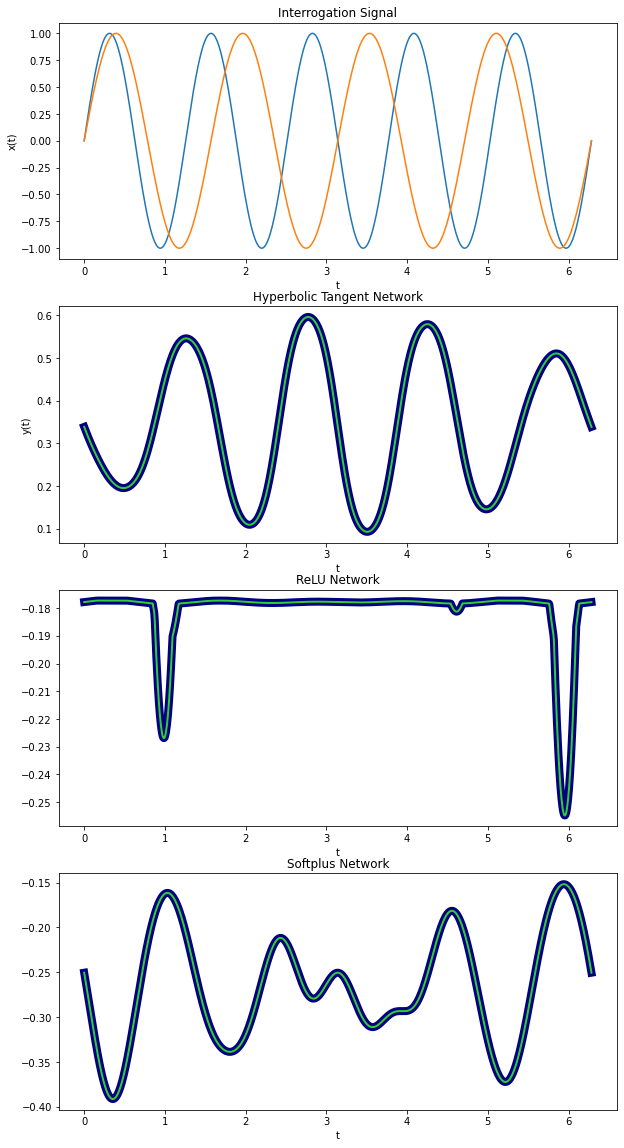

In [8]:
fig, axs = plt.subplots(4,1, figsize=(10,20))

axs[0].set_title('Interrogation Signal')
axs[0].set_xlabel('t')
axs[0].set_ylabel('x(t)')
axs[0].plot(t, x)

axs[1].set_title('Hyperbolic Tangent Network')
axs[1].set_xlabel('t')
axs[1].set_ylabel('y(t)')
axs[1].plot(t, y_tanh, color='navy', linewidth=8)
axs[1].plot(t, y_tanh_eq, color='limegreen', linewidth=2)

axs[2].set_title('ReLU Network')
axs[2].set_xlabel('t')
axs[2].set_label('y(t)')
axs[2].plot(t, y_relu, color='navy', linewidth=8)
axs[2].plot(t, y_relu_eq, color='limegreen', linewidth=2)

axs[3].set_title('Softplus Network')
axs[3].set_xlabel('t')
axs[3].set_label('y(t)')
axs[3].plot(t, y_softplus, color='navy', linewidth=8)
axs[3].plot(t, y_softplus_eq, color='limegreen', linewidth=2)
